In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Trav_clan(Hotel_bookings_final).csv")

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows : 30000
Columns : 24


,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


# we are just analysing the data and trying to understand the patterns and trends that emerge from it. By examining the data closely, we can identify key insights that can inform our decision-making process and help us make more informed choices in the future.

In [ ]:
df.info()
df.columns.tolist()

-- Missing Values Analysis

In [ ]:
df.isnull().sum()

-- Duplicate Check

In [10]:
df.duplicated().sum()

np.int64(0)

Data Type Conversion 

In [12]:
date_cols = [
    "booking_date",
    "check_in_date",
    "check_out_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [ ]:
df.info()

Stay Length


In [15]:
df["stay_length"] = (
    df["check_out_date"] - df["check_in_date"]
).dt.days

Booking Month

In [16]:
df["booking_month"] = df["booking_date"].dt.month_name()

Buisness metrics


In [17]:
print("Total Revenue:", df["selling_price"].sum())

print("Total Cost:", df["costprice"].sum())

print("Total Profit:",
      (df["selling_price"] - df["costprice"]).sum())

Total Revenue: 885144555
Total Cost: 676244823
Total Profit: 208899732


In [34]:
df["profit"] = df["selling_price"] - df["costprice"]

df["profit"].head()
df.groupby("star_rating")["selling_price"].sum().sort_values(ascending=False)

star_rating
4    354841176
3    310134032
5    131677093
2     88492254
Name: selling_price, dtype: int64

Booking Channel Distribution

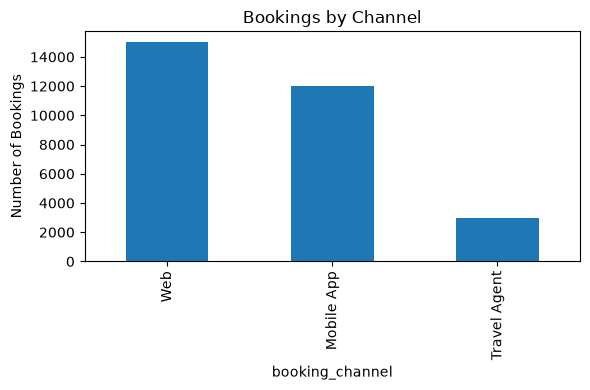

In [35]:
channel_counts = df["booking_channel"].value_counts()

plt.figure(figsize=(6,4))
channel_counts.plot(kind="bar")
plt.title("Bookings by Channel")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.savefig("../output/bookings_by_channel.png")
plt.show()

Cancellation Rate by Channel

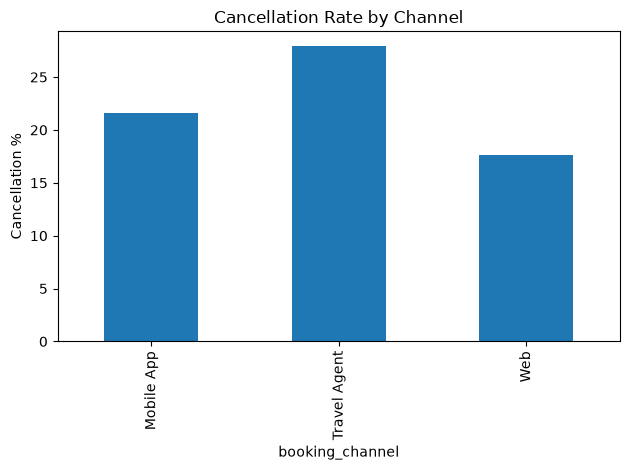

In [36]:
channel_cancel = pd.crosstab(
    df["booking_channel"],
    df["booking_status"],
    normalize="index"
) * 100

channel_cancel["Cancelled"].plot(kind="bar")

plt.title("Cancellation Rate by Channel")
plt.ylabel("Cancellation %")
plt.tight_layout()
plt.savefig("../output/cancellation_by_channel.png")
plt.show()

Room Type Distribution

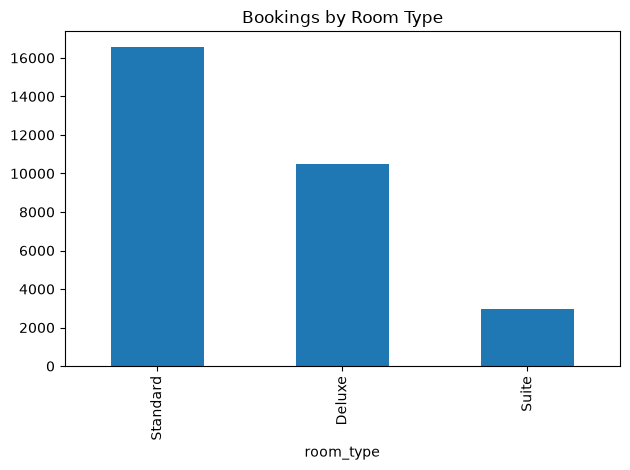

In [37]:
df["room_type"].value_counts().plot(kind="bar")

plt.title("Bookings by Room Type")
plt.tight_layout()
plt.savefig("../output/room_type_distribution.png")
plt.show()

Revenue by Star Rating

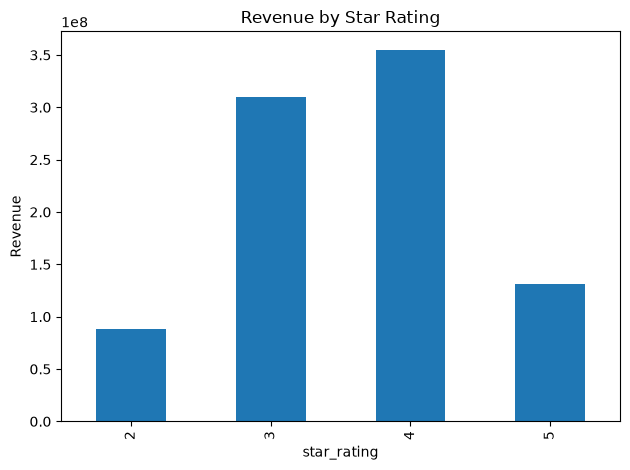

In [38]:
df.groupby("star_rating")["selling_price"].sum().plot(kind="bar")

plt.title("Revenue by Star Rating")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("../output/revenue_by_star_rating.png")
plt.show()

Monthly Booking Trend

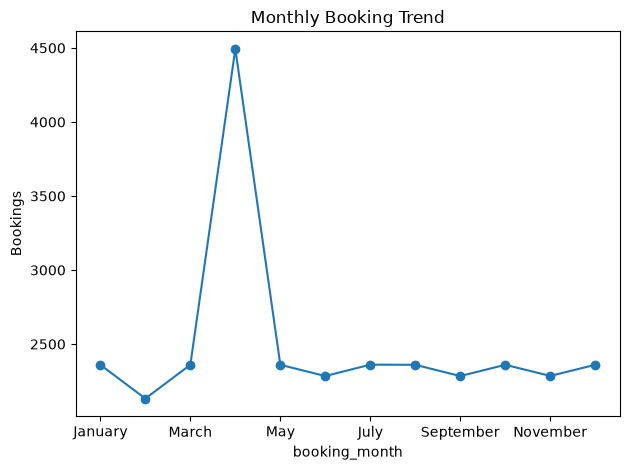

In [39]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = df["booking_month"].value_counts().reindex(month_order)

monthly.plot(kind="line", marker="o")

plt.title("Monthly Booking Trend")
plt.ylabel("Bookings")
plt.tight_layout()
plt.savefig("../output/monthly_booking_trend.png")
plt.show()

Root Cause 1

Travel Agent bookings show highest cancellation rate (~28%).

Possible reasons:

Less customer commitment
Delayed confirmations
Price mismatch
Third-party dependency

Root Cause 2

Standard rooms have highest cancellation rate (~23%).

Possible reasons:

Budget travelers are more price sensitive.
Easier to switch between competing hotels.

Root Cause 3

April shows unusually high booking demand.

Possible reasons:

Vacation season
Holiday period
Seasonal travel demand

Business Recommendations

Markdown cell:

# Recommendation 1

Reduce Travel Agent dependency and strengthen Web channel.

# Recommendation 2

Offer early check-in benefits for direct bookings.

# Recommendation 3

Introduce non-refundable discounted plans.

# Recommendation 4

Provide loyalty rewards for repeat customers.

# Recommendation 5

Increase pricing slightly during peak-demand periods like April. 

In [41]:
df.groupby("booking_status")["profit"].sum()

booking_status
Cancelled     42400444
Confirmed    150750257
Failed        15749031
Name: profit, dtype: int64